In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

In [2]:
df = pd.read_csv("diamonds.csv")

In [3]:
df.sample(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
11645,0.31,Very Good,G,VVS1,58.8,59.0,778,4.44,4.47,2.62
2007,1.03,Very Good,G,VS1,61.3,56.1,7511,6.50,6.52,3.99
5219,0.30,Ideal,G,IF,62.0,56.0,895,4.30,4.31,2.67
17392,0.32,Premium,G,VS1,60.6,60.0,828,4.44,4.40,2.68
52780,0.71,Ideal,G,VS1,62.2,56.0,2962,5.69,5.72,3.55
29671,0.50,Premium,D,VS2,62.8,58.0,1845,5.08,5.05,3.18
48669,1.04,Ideal,F,I1,61.6,57.0,3718,6.51,6.46,4.00
20314,0.71,Premium,F,SI1,60.2,60.0,2345,5.79,5.71,3.46
19405,0.52,Ideal,D,VS2,62.3,56.0,1822,5.11,5.16,3.20
17175,0.63,Good,H,IF,59.3,62.0,2404,5.66,5.70,3.37


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53941 entries, 0 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53941 non-null  float64
 1   cut      53941 non-null  object 
 2   color    53941 non-null  object 
 3   clarity  53941 non-null  object 
 4   depth    53941 non-null  float64
 5   table    53941 non-null  float64
 6   price    53941 non-null  int64  
 7   x        53941 non-null  float64
 8   y        53941 non-null  float64
 9   z        53941 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


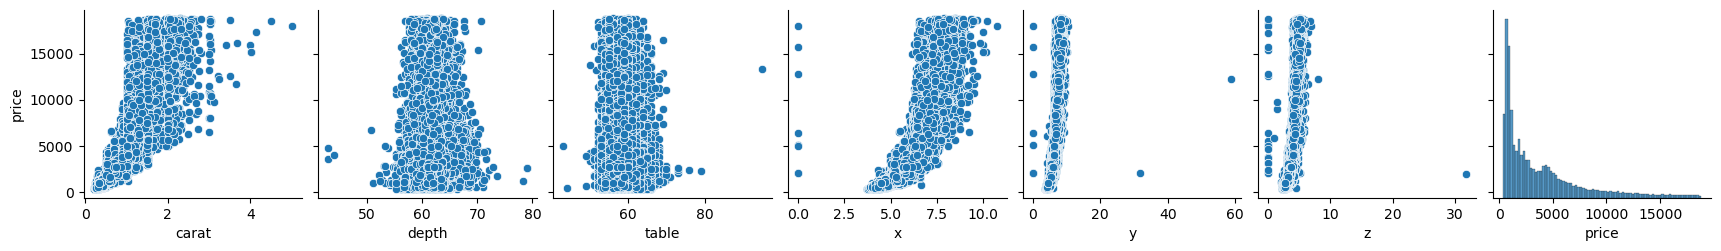

In [12]:
num_cols=["carat", "depth", "table", "x", "y", "z","price"]
sns.pairplot(df, y_vars="price", x_vars=num_cols)

In [14]:
df[num_cols].corr()

,carat,depth,table,x,y,z,price
carat,1.000000,0.028266,0.181643,0.975095,0.951724,0.953389,0.921593
depth,0.028266,1.000000,-0.295735,-0.025252,-0.029301,0.094964,-0.010613
table,0.181643,-0.295735,1.000000,0.195365,0.183783,0.150955,0.127155
x,0.975095,-0.025252,0.195365,1.000000,0.974702,0.970772,0.884438
y,0.951724,-0.029301,0.183783,0.974702,1.000000,0.952007,0.865425
z,0.953389,0.094964,0.150955,0.970772,0.952007,1.000000,0.861253
price,0.921593,-0.010613,0.127155,0.884438,0.865425,0.861253,1.000000


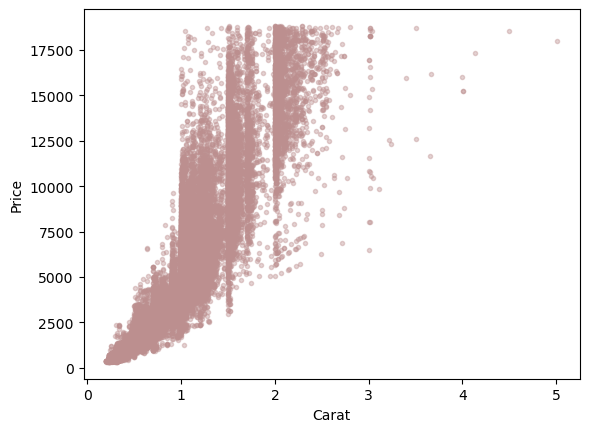

In [21]:
plt.scatter(df["carat"],df["price"], alpha=0.4, color="RosyBrown", marker=".")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

In [29]:
Y = df["price"]
X = df["carat"]
X = sm.add_constant(X)

In [31]:
Y

0         326
1         326
2         327
3         334
4         335
         ... 
53936    2757
53937    2757
53938    2757
53939    2757
53940    2757
Name: price, Length: 53941, dtype: int64

In [32]:
X

,const,carat
0,1.0,0.23
1,1.0,0.21
2,1.0,0.23
3,1.0,0.29
4,1.0,0.31
...,...,...
53936,1.0,0.72
53937,1.0,0.72
53938,1.0,0.70
53939,1.0,0.86


In [35]:
# create model
model=sm.OLS(Y, X)

In [36]:
# training the model
results = model.fit()

In [37]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:43:52   Log-Likelihood:            -4.7274e+05
No. Observations:               53941   AIC:                         9.455e+05
Df Residuals:                   53939   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3385     13.055   -172.831      0.0

In [38]:
# R^2: Coeff of Determination: proportion of variance of dep var that is predictable from the ind var >> 
# tells how well the model fits the data

In [39]:
results.params

const   -2256.338481
carat    7756.379377
dtype: float64

In [40]:
m = results.params["carat"]
b = results.params["const"]

In [42]:
df.loc[2007]

carat           1.03
cut        Very Good
color              G
clarity          VS1
depth           61.3
table           56.1
price           7511
x                6.5
y               6.52
z               3.99
Name: 2007, dtype: object

In [43]:
carat = 1.03
price=m*carat+b
print(price)

5732.73227738799


In [44]:
carats = np.random.uniform(low=0, high=5, size=20)
carats

array([0.65306766, 0.23177519, 0.7362342 , 0.81804745, 3.48211534,
       4.13432498, 0.15465265, 3.01439151, 0.10508312, 3.07585443,
       2.91059519, 1.09629864, 2.19080703, 1.23960917, 2.17688331,
       3.27519166, 2.22058955, 2.80279948, 1.99058103, 4.43448099])

In [45]:
prices = m*carats + b
prices

array([ 2809.10206385,  -458.60215954,  3454.17329791,  4088.74790464,
       24752.26914318, 29811.0545615 , -1056.79389361, 21124.42562971,
       -1441.27392013, 21601.15538894, 20319.34199225,  6246.96971134,
       14736.39198525,  7358.54050596, 14628.39432538, 23147.29058086,
       14967.39653265, 19483.23762453, 13183.36318249, 32139.17840509])

<Axes: xlabel='carat', ylabel='price'>

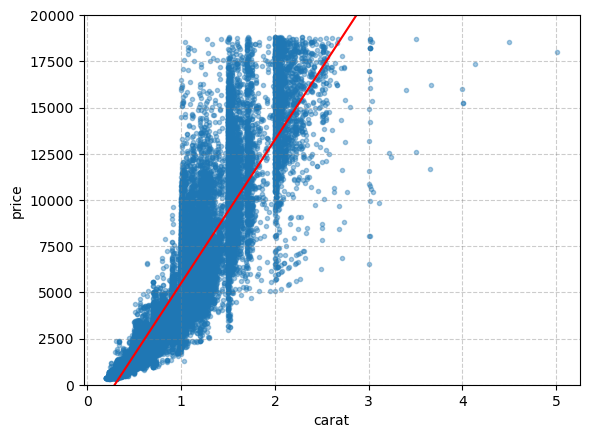

In [49]:
plt.scatter(df["carat"], df["price"], alpha=0.4, marker=".")

plt.ylabel("price")
plt.ylim(0,20000)
plt.grid(color="gray", linestyle="--", alpha=0.4)

line = m * df["carat"] + b

sns.lineplot(x=df["carat"], y=line, color="red")

-----

In [52]:
predictors=["carat","x","y","z"]

Y = df["price"]
X = df[predictors]

X = sm.add_constant(X)

In [53]:
X

,const,carat,x,y,z
0,1.0,0.23,3.95,3.98,2.43
1,1.0,0.21,3.89,3.84,2.31
2,1.0,0.23,4.05,4.07,2.31
3,1.0,0.29,4.20,4.23,2.63
4,1.0,0.31,4.34,4.35,2.75
...,...,...,...,...,...
53936,1.0,0.72,5.75,5.76,3.50
53937,1.0,0.72,5.69,5.75,3.61
53938,1.0,0.70,5.66,5.68,3.56
53939,1.0,0.86,6.15,6.12,3.74


In [54]:
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 7.892e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:34:14   Log-Likelihood:            -4.7188e+05
No. Observations:               53941   AIC:                         9.438e+05
Df Residuals:                   53936   BIC:                         9.438e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1921.0000    104.372     18.405      0.0

In [55]:
results.params

const     1921.000030
carat    10233.738814
x         -884.066331
y          166.013970
z         -576.311510
dtype: float64

In [56]:
m1 = results.params["carat"]
m2 = results.params["x"]
m3=results.params["y"]
m4=results.params["z"]
b = results.params["const"]


In [58]:
df.loc[500]

carat           1.51
cut        Very Good
color              H
clarity          SI2
depth           60.2
table           59.0
price           8444
x               7.33
y               7.43
z               4.44
Name: 500, dtype: object

In [59]:
carat= 1.51
x=7.33
y=7.43
z=4.44
price = m1*carat + m2*x + m3*y + m4*z + b
price

np.float64(9568.400122718987)

In [60]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [64]:
pd.unique(df["color"])

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [65]:
df["color"].sort_values()

53940    D
31633    D
31637    D
31644    D
7768     D
        ..
4802     J
40425    J
17020    J
50388    J
6983     J
Name: color, Length: 53941, dtype: object

/var/folders/6h/h489k5ln6r93tz_q7ssx2hj00000gn/T/ipykernel_49830/813468897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x="color", y="price", order=color_order, palette="YlOrBr")


<Axes: xlabel='color', ylabel='price'>

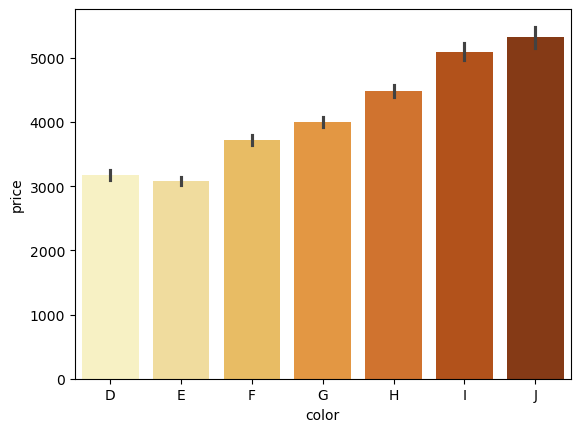

In [82]:
color_order = pd.unique(df["color"].sort_values())

sns.barplot(df, x="color", y="price", order=color_order, palette="YlOrBr")

In [78]:
predictors = ["carat", "color"]

Y = df["price"]
X = df[predictors]

X = sm.add_constant(pd.get_dummies(X, columns=["color"], dtype=int, drop_first=True))

In [79]:
X

,const,carat,color_E,color_F,color_G,color_H,color_I,color_J
0,1.0,0.23,1,0,0,0,0,0
1,1.0,0.21,1,0,0,0,0,0
2,1.0,0.23,1,0,0,0,0,0
3,1.0,0.29,0,0,0,0,1,0
4,1.0,0.31,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...
53936,1.0,0.72,0,0,0,0,0,0
53937,1.0,0.72,0,0,0,0,0,0
53938,1.0,0.70,0,0,0,0,0,0
53939,1.0,0.86,0,0,0,1,0,0


In [83]:
X_train = X[1000:]
X_test = X[:1000]
Y_train= Y[1000:]
Y_test=Y[:1000]

In [85]:
model = sm.OLS(Y_train, X_train)
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 4.805e+04
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:10:30   Log-Likelihood:            -4.6119e+05
No. Observations:               52941   AIC:                         9.224e+05
Df Residuals:                   52933   BIC:                         9.225e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2136.8108     20.269   -105.421      0.0

In [87]:
predicted = results.predict(X_test)

In [88]:
predicted

0      -376.053034
1      -537.354322
2      -376.053034
3      -852.813195
4     -1550.781485
          ...     
995    9866.578738
996    9311.819500
997    7625.108272
998    1166.104469
999    1004.803182
Length: 1000, dtype: float64

In [89]:
predicted.describe()

count     1000.000000
mean      4176.332288
std       3903.570993
min      -1631.432129
25%        995.007912
50%       3431.274790
75%       6189.103560
max      26571.057289
dtype: float64

In [91]:
X_test.loc[28]

const      1.00
carat      0.41
color_E    0.00
color_F    1.00
color_G    0.00
color_H    0.00
color_I    0.00
color_J    0.00
Name: 28, dtype: float64

In [92]:
Y_test.loc[28]

np.int64(1192)

In [93]:
predicted.loc[28]

np.float64(1092.4061181261159)

In [94]:
y_pred = results.predict(X_test)

In [95]:
y_actual = Y_test

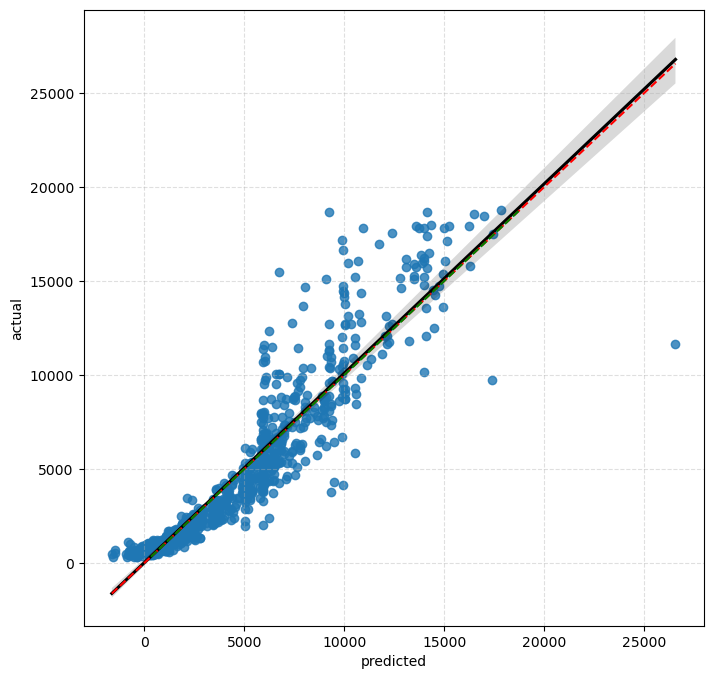

In [105]:
plt.figure(figsize=(8,8))

sns.regplot(x=y_pred, y=y_actual, line_kws={"color":"black"})

plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], color="red", linestyle="--")
plt.plot([min(y_actual), max(y_actual)], [min(y_actual), max(y_actual)], color="green", linestyle="--")

plt.grid(linestyle="--", alpha=0.4)

plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()